# Generator-Critic — LangGraph Implementation

> "The model critiques; the harness decides."

This notebook implements Generator-Critic as a **LangGraph `StateGraph`**:

`generate -> critique -> gate -> optional revise -> END`

The graph version is intentionally explicit. Every role is a node, the policy branch is a conditional edge, and the revision path is visible in the rendered graph. The [LangChain version](../langchain/tutorial.ipynb) implements the same data and policy as LCEL runnables.

Everything runs against deterministic fake roles first (no API key needed), then the real backend. Default: AI Studio + `ernie-5.1` (OpenAI-compatible). See [`.env.example`](../../../.env.example) for provider config and [`model_config.py`](../../../model_config.py) for the shared loader.

## What this pattern does

Generator-Critic separates three jobs that often get blurred together:

1. **Generate** the artifact under review.
2. **Critique** the artifact as structured evidence: score, summary, issues.
3. **Gate** the artifact in deterministic code.

The key design choice: **revision is not acceptance**. If the critic finds a blocker or the score is too low, this pass may draft a revision, but it ends as `needs_revision`. The revised artifact must go through a fresh critique before it can pass.

| | `langgraph/` (StateGraph) | `langchain/` (LCEL) |
|---|---|---|
| **The roles are** | Explicit nodes: `generate`, `critique`, `gate`, `revise` | Runnables: generator pipe, critic pipe, policy runnable |
| **The branch is** | `add_conditional_edges("gate", ...)` | Code inside a `RunnableLambda` gate |
| **Mock roles** | Plain Python callables from `shared.py` | `FakeListChatModel` responses in call order |
| **Safety boundary** | Revision path ends at `END` | Same: no auto-accept after revision |
| **Trade-off** | More code, every transition visible | Less code, control flow implicit |


## Setup

The mock cells are deterministic and need no API key. The real-backend section at the end calls `get_model()` directly; when no model is configured, it skips with a short message.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
from typing import Callable, TypedDict

# shared.py lives in the pattern folder; model_config.py and nbtools.py live at
# the repo root. Search upward for each marker so this notebook works from
# JupyterLab, nbmake, nbconvert, or the repo root without brittle ../../ paths.
for _marker in ("shared.py", "model_config.py", "nbtools.py"):
    _dir = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / _marker).exists())
    sys.path.insert(0, str(_dir))

from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph

from model_config import get_model
from nbtools import show_graph
from pattern import Artifact, ChainResult, Critique, Decision
from shared import (
    BAD_CRITIQUE_JSON,
    CRITIC_SYSTEM_PROMPT,
    DEFAULT_PROMPT,
    GENERATOR_SYSTEM_PROMPT,
    GOOD_CRITIQUE_JSON,
    LOW_SCORE_CRITIQUE_JSON,
    NEEDS_REVISION_CRITIQUE_JSON,
    default_policy,
    parse_critique_json,
    print_trace,
    revise_with_evidence,
    scripted_critic,
    scripted_generator,
)


## State and role interfaces

The graph state is small on purpose:

- `prompt` is the user request for the artifact.
- `artifact` is the generated or revised `Artifact`.
- `critique` is the parsed evidence from the critic.
- `decision` is the deterministic policy verdict.
- `trace` is a short audit path for the tutorial output.

The graph accepts plain Python callables for each role. That is why the fake roles in this notebook are framework-agnostic functions instead of LangChain fake chat models.

In [2]:
class ReviewState(TypedDict, total=False):
    prompt: str
    artifact: Artifact
    critique: Critique
    decision: Decision
    trace: list[str]


GeneratorFn = Callable[[str], Artifact]
CriticFn = Callable[[Artifact], Critique]
ReviserFn = Callable[[Artifact, Critique], Artifact]


## Core nodes

Each node owns exactly one role:

- `generate_node` calls the generator and starts the trace.
- `critique_node` calls the critic and appends evidence to state.
- `gate_node` runs `AcceptancePolicy`; it does not ask the LLM to decide.
- `revise_node` drafts a revised artifact when requested.

The conditional edge after `gate` is the whole safety boundary. If the artifact needs revision and a reviser exists, the graph routes to `revise`; otherwise it ends. The `revise` node also ends the graph, so revised text cannot be accepted in the same pass.

In [3]:
def build_graph(
    generator: GeneratorFn,
    critic: CriticFn,
    reviser: ReviserFn | None = None,
    *,
    policy=None,
):
    policy = policy or default_policy()

    def generate_node(state: ReviewState) -> dict:
        artifact = generator(state["prompt"])
        return {"artifact": artifact, "trace": ["generated"]}

    def critique_node(state: ReviewState) -> dict:
        critique = critic(state["artifact"])
        return {"critique": critique, "trace": state.get("trace", []) + ["critiqued"]}

    def gate_node(state: ReviewState) -> dict:
        # The critic provides evidence; AcceptancePolicy owns the decision.
        decision = policy.decide(state["critique"])
        return {"decision": decision, "trace": state.get("trace", []) + [decision.value]}

    def revise_node(state: ReviewState) -> dict:
        if reviser is None:
            return {}
        # Revision is a draft artifact only. The graph ends here so the revised
        # text cannot be accepted without a separate generate/critique/gate pass.
        artifact = reviser(state["artifact"], state["critique"])
        return {"artifact": artifact, "trace": state.get("trace", []) + ["revision_drafted"]}

    def route_after_gate(state: ReviewState) -> str:
        if state["decision"] is Decision.NEEDS_REVISION and reviser is not None:
            return "revise"
        return "done"

    builder = StateGraph(ReviewState)
    builder.add_node("generate", generate_node)
    builder.add_node("critique", critique_node)
    builder.add_node("gate", gate_node)
    builder.add_node("revise", revise_node)
    builder.add_edge(START, "generate")
    builder.add_edge("generate", "critique")
    builder.add_edge("critique", "gate")
    builder.add_conditional_edges("gate", route_after_gate, {"revise": "revise", "done": END})
    builder.add_edge("revise", END)
    return builder.compile()


def result_from_state(state: ReviewState) -> ChainResult:
    return ChainResult(
        decision=state["decision"],
        artifact=state["artifact"],
        critique=state["critique"],
        trace=state["trace"],
    )


## Deterministic fake roles

LangGraph does not require a LangChain model object. The graph only needs callables matching `GeneratorFn` and `CriticFn`, so the mock roles stay plain Python:

- `scripted_generator(prompt)` returns the canned artifact.
- `scripted_critic(raw_json)` returns a critic callable that replays one JSON payload through the shared parser.

That mirrors the guidance in `REFERENCE_IMPL.md`: use `FakeListChatModel` for LangChain LCEL pipes, but keep LangGraph fakes framework-agnostic when the graph accepts bare callables.

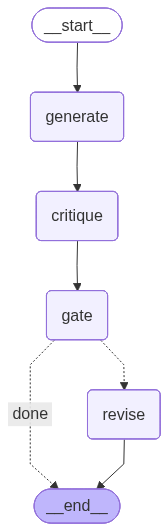

In [4]:
accepted_graph = build_graph(
    scripted_generator,
    scripted_critic(GOOD_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
show_graph(accepted_graph, alt="Generator-Critic LangGraph")


## Mock run 1: clean critique accepts

The generator returns the incident update and the critic returns a high score with no issues. The gate accepts. The trace is short because each graph node appends exactly one event.

In [5]:
state = accepted_graph.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result_from_state(state))


decision: accepted
trace: generated -> critiqued -> accepted
score: 0.9
issues: none
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes.


## Mock run 2: blocker drafts a revision, but does not auto-accept

The blocker issue routes through `revise`, and the reviser adds evidence to the artifact. The decision remains `needs_revision`; the revision is a draft for the next pass, not an accepted result.

In [6]:
revision_graph = build_graph(
    scripted_generator,
    scripted_critic(NEEDS_REVISION_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
state = revision_graph.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result_from_state(state))


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.74
issues: ['blocker:sentence 2:impact claim lacks a cited source']
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Mock run 3: low score without blockers still fails

Here the critic returns only a warning, but the score is below the default threshold. This demonstrates that the policy is more than a blocker check: score and issue severity both matter.

In [7]:
low_score_graph = build_graph(
    scripted_generator,
    scripted_critic(LOW_SCORE_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
state = low_score_graph.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result_from_state(state))


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.62
issues: ['warning:sentence 3:next update timing is too vague']
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Mock run 4: malformed critic output fails closed

The critic returns invalid JSON. The shared parser converts that parse failure into a blocker `Critique`, so the graph takes the revision branch instead of accidentally accepting the artifact.

In [8]:
parse_failure_graph = build_graph(
    scripted_generator,
    scripted_critic(BAD_CRITIQUE_JSON),
    reviser=revise_with_evidence,
)
state = parse_failure_graph.invoke({"prompt": DEFAULT_PROMPT})
print_trace(result_from_state(state))


decision: needs_revision
trace: generated -> critiqued -> needs_revision -> revision_drafted
score: 0.0
issues: ['blocker:critic:critic output could not be parsed: JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)']
artifact: We identified elevated checkout errors. Impact is limited to card payments. Next update in 30 minutes. Evidence: status dashboard incident INC-42.


## Real backend

The live run uses the same graph shape. We swap fake role callables for real role callables, then pass them to `build_graph`:

- fake: `build_graph(scripted_generator, scripted_critic(...))`
- real: `build_graph(real_generator, real_critic)`

`get_model()` is the only boundary. If no provider key is configured, it returns `None` and the cell skips. For deterministic notebook verification, run tests with provider API keys unset rather than adding a notebook-specific fake/real mode flag.

In [9]:
model = get_model()

if model is None:
    print("No model configured — skipping real backend run. See .env.example to enable.")
else:
    def real_generator(prompt: str) -> Artifact:
        response = model.invoke([
            SystemMessage(content=GENERATOR_SYSTEM_PROMPT),
            HumanMessage(content=prompt),
        ])
        return Artifact(content=str(response.content), metadata={"source": "real_model"})

    def real_critic(artifact: Artifact) -> Critique:
        response = model.invoke([
            SystemMessage(content=CRITIC_SYSTEM_PROMPT),
            HumanMessage(content=artifact.content),
        ])
        return parse_critique_json(str(response.content))

    try:
        real_graph = build_graph(real_generator, real_critic)
        state = real_graph.invoke({"prompt": DEFAULT_PROMPT})
        print_trace(result_from_state(state))
    except Exception as exc:  # noqa: BLE001
        # Provider outages, auth failures, and rate limits are reported instead
        # of crashing the tutorial. Parser failures still fail closed inside the
        # graph and show up as a needs_revision result.
        print(f"Real backend failed gracefully: {type(exc).__name__}: {exc}")


Model: ernie:ernie-5.1


decision: needs_revision
trace: generated -> critiqued -> needs_revision
score: 0.3
issues: ['blocker:Body of the update:No specific description of the checkout issue (e.g., payment processing, cart errors).', 'blocker:Body of the update:No estimated time of resolution (ETR) or timeline provided.']
artifact: **Subject: Checkout Issue Update**
Dear Customers,
We are experiencing a checkout issue and are working to fix it. Please try again later. We apologize for the inconvenience and thank you for your patience.


## Composing as a subgraph

A compiled Generator-Critic graph is a normal LangGraph runnable. A larger agent could route only high-risk outputs through this reviewer before releasing them:

```python
parent = StateGraph(AgentState)
parent.add_node("draft", draft_node)
parent.add_node("generator_critic", accepted_graph)  # compiled graph as a node
parent.add_conditional_edges("draft", route_if_review_needed, {
    "review": "generator_critic",
    "skip": END,
})
```

That composition point is why the revision boundary matters. If `generator_critic` returns `needs_revision`, the parent graph can send it to an editor, queue it for human review, or run a second pass explicitly.

## What to remember

- `StateGraph` makes the safety boundary visible: `generate -> critique -> gate -> revise -> END`.
- The critic returns evidence, not approval authority.
- `AcceptancePolicy` owns both score threshold and blocker logic.
- Parser failures fail closed as blocker critiques.
- A revision draft is not accepted until another pass critiques it.

## Further reading

- [LangChain version](../langchain/tutorial.ipynb) — same pattern as LCEL pipes and a runnable policy gate
- [Pattern README](../README.md) — design rationale and Python core implementation
- [Reference implementation guide](../../../REFERENCE_IMPL.md) — repo conventions, fake-model guidance, notebook verification commands
- [StateGraph reference](https://langchain-ai.github.io/langgraph/reference/graphs/)
